In [26]:
# ==============================================================================
# Development and Internal Validation of Clinical Prediction Models for MASLD
# Amol Cohort Study (AmolCS) - 7-Year Risk Prediction
# Coded By Masoud Imani
# Email: Masoudimani7@gmail.com
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.stats import chi2

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, brier_score_loss, average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from tableone import TableOne

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not found. Pipeline will skip XGBoost evaluation.")

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x  

import warnings
warnings.filterwarnings('ignore')

# Global Reproducibility Settings
RANDOM_STATE = 42
N_SPLITS = 5
THRESHOLDS = np.arange(0.10, 0.52, 0.02)
OPTIMIZE_METRIC = "youden"

# ==============================================================================
# PHASE 1: COHORT CONSTRUCTION & ATTRITION ANALYSIS
# ==============================================================================
print("Loading data...")
df = pd.read_csv("Updated_MASLD.csv")
print(f"Initial Enrolled Participants: {len(df)}")

def yn_to01(s):
    return s.astype('string').str.strip().str.lower().map(
        {'yes': 1, 'y': 1, '1': 1, 'true': 1, 'no': 0, 'n': 0, '0': 0, 'false': 0}
    ).astype('Int64')

# 1. Feature Engineering
bp_cols = ['sbp1_1', 'sbp1_2', 'dbp1_1', 'dbp1_2']
df[bp_cols] = df[bp_cols].apply(pd.to_numeric, errors='coerce')
df['sbp_mean'] = df[['sbp1_1', 'sbp1_2']].mean(axis=1)
df['dbp_mean'] = df[['dbp1_1', 'dbp1_2']].mean(axis=1)

df['measureweight_1'] = pd.to_numeric(df['measureweight_1'], errors='coerce')
df['measurelength_1'] = pd.to_numeric(df['measurelength_1'], errors='coerce')
h_m = df['measurelength_1'] / 100.0
valid = (df['measureweight_1'] > 0) & (h_m > 0)
df['BMI (kg/m^2)'] = np.where(valid, df['measureweight_1'] / (h_m ** 2), np.nan)

# 2. Target Definition & Follow-up Tracking
df['m_masld_1_clean'] = yn_to01(df['m_masld_1'])
df['m_masld_2_clean'] = yn_to01(df['m_masld_2'])
inc_raw = df['m_masld_incidence'].astype('string').str.strip().str.lower()
df['inc_clean'] = inc_raw.map({'incidence': 1, 'negative': 0, 'regress': pd.NA}).astype('Int64')

df['target'] = df['inc_clean'].copy()
need_fill = df['target'].isna() & df['m_masld_2_clean'].notna()
df.loc[need_fill, 'target'] = df.loc[need_fill, 'm_masld_2_clean']

mask_has_outcome = df['target'].notna() & (inc_raw != 'regress')

# 3. SMD for Loss to Follow-up 
print("\n--- SMD for Loss to Follow-up (Retained vs Lost) ---")
print(f"Retained: {mask_has_outcome.sum()} | Lost: {(~mask_has_outcome).sum()}")
for var in ['age_m', 'BMI (kg/m^2)', 'alt_1', 'ast_1', 'tg_1', 'sbp_mean']:
    df[var] = pd.to_numeric(df[var], errors='coerce')
    mean1, std1 = df.loc[mask_has_outcome, var].mean(), df.loc[mask_has_outcome, var].std()
    mean2, std2 = df.loc[~mask_has_outcome, var].mean(), df.loc[~mask_has_outcome, var].std()
    smd = np.abs(mean1 - mean2) / np.sqrt((std1**2 + std2**2) / 2)
    print(f"{var:15s} SMD = {smd:.3f}")

# 4. Exclusions & Sensitivity Analysis 
df_step1 = df[mask_has_outcome].copy()
df_step2 = df_step1[df_step1['m_masld_1_clean'] == 0].copy()

df_step2['m_sld_1_clean'] = yn_to01(df_step2['m_sld_1'])
mask_isolated_steatosis = df_step2['m_sld_1_clean'] == 1
df_step3 = df_step2[~mask_isolated_steatosis].copy()
print(f"\nDropped {mask_isolated_steatosis.sum()} patients with isolated baseline steatosis.")

mask_hepatitis = df_step3[['m_hbsag_1', 'm_hcvab_1']].eq('Yes').any(axis=1)
df_step4 = df_step3[~mask_hepatitis].copy()

df_step4['m_cirrhosis_1'] = pd.to_numeric(df_step4['m_cirrhosis_1'], errors='coerce')
df_final = df_step4[df_step4['m_cirrhosis_1'] != 1].copy()

print(f"---> FINAL AT-RISK COHORT SIZE: {len(df_final)}")

# 5. Final Feature Matrix Preparation
model_vars = [
    'alt_1', 'ast_1', 'tg_1', 'hdl_1', 'ldl_1', 'sex', 'age_m',
    'm_hbsab_1', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1',
    'm_t2dm_1', 'sbp_mean', 'dbp_mean', 'BMI (kg/m^2)'
]

X = df_final[model_vars].copy()
for c in X.columns:
    if X[c].dtype == "object" or X[c].dtype == "string":
        s = X[c].astype("string").str.strip().str.lower()
        if c.lower() == 'sex':
            s = s.replace({"m": "1", "male": "1", "f": "0", "female": "0"})
        else:
            s = s.replace({"yes": "1", "no": "0", "true": "1", "false": "0"})
        X[c] = pd.to_numeric(s, errors='coerce')

y = df_final['target'].astype(int).copy()

Loading data...
Initial Enrolled Participants: 5398

--- SMD for Loss to Follow-up (Retained vs Lost) ---
Retained: 3819 | Lost: 1572
age_m           SMD = 0.333
BMI (kg/m^2)    SMD = 0.079
alt_1           SMD = 0.097
ast_1           SMD = 0.029
tg_1            SMD = 0.045
sbp_mean        SMD = 0.098

Dropped 276 patients with isolated baseline steatosis.
---> FINAL AT-RISK COHORT SIZE: 2354


In [27]:
# ==============================================================================
# PHASE 2: BASELINE CHARACTERISTICS (TABLE 1)
# ==============================================================================
df_table1 = X.copy()
df_table1['Incident_MASLD'] = y.values
df_table1['Incident_MASLD'] = df_table1['Incident_MASLD'].map({0: 'No MASLD (Healthy)', 1: 'Developed MASLD'})

cat_cols = ['sex', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1', 'm_t2dm_1', 'm_hbsab_1']
for col in cat_cols:
    if col in df_table1.columns:
        if col == 'sex':
            df_table1[col] = df_table1[col].map({0.0: 'Female', 1.0: 'Male'})
        else:
            df_table1[col] = df_table1[col].map({0.0: 'No', 1.0: 'Yes'})

columns_to_summarize = ['age_m', 'BMI (kg/m^2)', 'sbp_mean', 'dbp_mean', 'alt_1', 'ast_1', 'tg_1', 'hdl_1', 'ldl_1'] + cat_cols
non_normal_variables = ['alt_1', 'ast_1', 'tg_1']

rename_dict = {
    'age_m': 'Age (years)', 'sex': 'Sex', 'BMI (kg/m^2)': 'Body Mass Index (kg/m²)',
    'sbp_mean': 'Systolic BP (mmHg)', 'dbp_mean': 'Diastolic BP (mmHg)',
    'alt_1': 'ALT (U/L)', 'ast_1': 'AST (U/L)', 'tg_1': 'Triglycerides (mg/dL)',
    'hdl_1': 'HDL Cholesterol (mg/dL)', 'ldl_1': 'LDL Cholesterol (mg/dL)',
    'm_smoke_1': 'Current Smoker', 'm_metsatp3_1': 'Metabolic Syndrome (ATP III)',
    'm_lipm_1': 'Dyslipidemia', 'm_htnm_1': 'Hypertension', 'm_t2dm_1': 'Type 2 Diabetes',
    'm_hbsab_1': 'HBsAb Positive'
}

df_table1 = df_table1.rename(columns=rename_dict)
updated_columns = [rename_dict.get(c, c) for c in columns_to_summarize]
updated_categorical = [rename_dict.get(c, c) for c in cat_cols]
updated_non_normal = [rename_dict.get(c, c) for c in non_normal_variables]

table1 = TableOne(
    data=df_table1, columns=updated_columns, categorical=updated_categorical,
    groupby='Incident_MASLD', nonnormal=updated_non_normal, pval=True, overall=True, missing=False
)

print(table1.tabulate(tablefmt="github"))
table1.to_excel("Table1_Baseline_Characteristics.xlsx")

|                                       |        | Overall           | Developed MASLD    | No MASLD (Healthy)   | P-Value   |
|---------------------------------------|--------|-------------------|--------------------|----------------------|-----------|
| n                                     |        | 2354              | 610                | 1744                 |           |
| Age (years), mean (SD)                |        | 42.7 (15.2)       | 42.9 (13.2)        | 42.6 (15.8)          | 0.649     |
| Body Mass Index (kg/m²), mean (SD)    |        | 25.7 (4.6)        | 28.2 (5.0)         | 24.8 (4.1)           | <0.001    |
| Systolic BP (mmHg), mean (SD)         |        | 112.4 (14.8)      | 115.1 (15.4)       | 111.5 (14.4)         | <0.001    |
| Diastolic BP (mmHg), mean (SD)        |        | 73.3 (12.2)       | 75.6 (12.4)        | 72.5 (12.1)          | <0.001    |
| ALT (U/L), median [Q1,Q3]             |        | 17.0 [13.0,24.0]  | 19.0 [14.0,27.0]   | 16.2 [12.0,23.0]   

In [28]:
# ==============================================================================
# PHASE 3: DATA SPLIT, STOCHASTIC IMPUTATION & BENCHMARKING
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
print(f"Dataset Split -> Train set: {len(X_train)} | Test set: {len(X_test)}")

# Pre-compute imputed sets explicitly for Statsmodels and Benchmark Model
print("Performing Stochastic MICE Imputation...")
imputer_base = IterativeImputer(max_iter=10, sample_posterior=True, random_state=RANDOM_STATE, initial_strategy='mean')
X_train_imp = pd.DataFrame(imputer_base.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imputer_base.transform(X_test), columns=X_test.columns, index=X_test.index)

binary_cols = ['sex', 'm_hbsab_1', 'm_smoke_1', 'm_metsatp3_1', 'm_lipm_1', 'm_htnm_1', 'm_t2dm_1']
for col in binary_cols:
    X_train_imp[col] = np.where(X_train_imp[col] > 0.5, 1.0, 0.0)
    X_test_imp[col] = np.where(X_test_imp[col] > 0.5, 1.0, 0.0)

# Parsimonious Benchmark Model (Reviewer Comment 6)
simple_vars = ['age_m', 'BMI (kg/m^2)', 'alt_1', 'tg_1']
simple_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, penalty='none', random_state=RANDOM_STATE))
])
simple_model.fit(X_train_imp[simple_vars], y_train)
y_prob_simple = simple_model.predict_proba(X_test_imp[simple_vars])[:, 1]
print(f"Simple Parsimonious Model (4 variables) ROC-AUC: {roc_auc_score(y_test, y_prob_simple):.3f}")

Dataset Split -> Train set: 1647 | Test set: 707
Performing Stochastic MICE Imputation...
Simple Parsimonious Model (4 variables) ROC-AUC: 0.714


--- Phase 1: RandomizedSearchCV Hyperparameter Tuning ---
Tuning LogisticRegression...
  -> Best CV AUC: 0.725
Tuning RandomForest...
  -> Best CV AUC: 0.725
Tuning MLP...
  -> Best CV AUC: 0.720
Tuning NaiveBayes...
  -> Best CV AUC: 0.685
Tuning XGBoost...
  -> Best CV AUC: 0.725

--- Phase 2: Threshold Optimization & Final Evaluation ---


Threshold Optimization CV:   0%|          | 0/25 [00:00<?, ?it/s]


--- 1. INTERNAL CROSS-VALIDATION RESULTS (Train Partition Only) ---


,BestThresh,CV Accuracy,CV Sensitivity,CV Specificity,CV Youden J,CV ROC AUC
Model,,,,,,
XGBoost,0.30,0.677 ± 0.028,0.668 ± 0.071,0.680 ± 0.020,0.348 ± 0.082,0.736 ± 0.039
LogisticRegression,0.26,0.685 ± 0.027,0.672 ± 0.068,0.689 ± 0.022,0.362 ± 0.077,0.730 ± 0.034
RandomForest,0.26,0.645 ± 0.019,0.726 ± 0.050,0.616 ± 0.012,0.342 ± 0.057,0.729 ± 0.035
MLP,0.20,0.639 ± 0.033,0.738 ± 0.048,0.604 ± 0.036,0.342 ± 0.068,0.725 ± 0.030
NaiveBayes,0.12,0.673 ± 0.017,0.588 ± 0.045,0.702 ± 0.020,0.290 ± 0.045,0.694 ± 0.030



--- 2. LOCKED TEST SET VALIDATION RESULTS (Unbiased Evaluation) ---


,AppliedThresh,Test Accuracy,Test Sensitivity,Test Specificity,Test Youden J,Test ROC AUC
Model,,,,,,
XGBoost,0.30,0.645,0.667,0.637,0.304,0.716
RandomForest,0.26,0.621,0.765,0.571,0.336,0.713
LogisticRegression,0.26,0.659,0.689,0.649,0.337,0.710
MLP,0.20,0.573,0.781,0.500,0.281,0.702
NaiveBayes,0.12,0.636,0.552,0.666,0.218,0.673


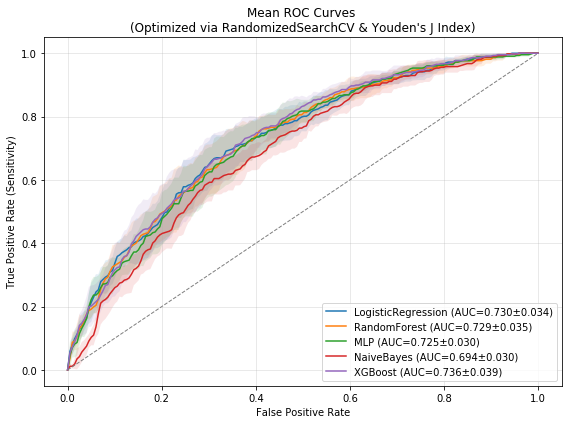

In [22]:
# ==============================================================================
# PHASE 4: RANDOMIZED SEARCH CV, OPTIMIZATION & COMPARATIVE EVALUATION
# ==============================================================================
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

def get_models_and_grids(random_state=RANDOM_STATE):
    scaler = StandardScaler()
    imputer = IterativeImputer(max_iter=10, sample_posterior=True, random_state=random_state, initial_strategy='mean')

    models = {
        "LogisticRegression": Pipeline([("imputer", clone(imputer)), ("scaler", scaler), ("clf", LogisticRegression(max_iter=1000, random_state=random_state))]),
        "RandomForest": Pipeline([("imputer", clone(imputer)), ("clf", RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
        "MLP": Pipeline([("imputer", clone(imputer)), ("scaler", scaler), ("clf", MLPClassifier(max_iter=500, early_stopping=True, random_state=random_state))]),
        "NaiveBayes": Pipeline([("imputer", clone(imputer)), ("scaler", scaler), ("clf", GaussianNB())]),
    }
    if HAS_XGB:
        models["XGBoost"] = Pipeline([("imputer", clone(imputer)), ("clf", XGBClassifier(random_state=random_state, n_jobs=-1, eval_metric="logloss"))])

    param_grids = {
        "LogisticRegression": {"clf__C": [0.01, 0.1, 1.0, 10.0], "clf__penalty": ["l2"]},
        "RandomForest": {"clf__n_estimators": [200, 300, 400], "clf__max_depth": [None, 5, 10, 15], "clf__min_samples_split": [2, 5, 10]},
        "MLP": {"clf__hidden_layer_sizes": [(32,), (64, 32), (128, 64)], "clf__alpha": [1e-4, 1e-3, 1e-2], "clf__learning_rate_init": [0.001, 0.005, 0.01]},
        "NaiveBayes": {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]},
        "XGBoost": {"clf__learning_rate": [0.01, 0.05, 0.1, 0.2], "clf__max_depth": [3, 4, 5, 6], "clf__n_estimators": [100, 300, 500], "clf__subsample": [0.8, 0.9, 1.0], "clf__colsample_bytree": [0.8, 0.9, 1.0]}
    }
    return models, param_grids

base_models, param_grids = get_models_and_grids(RANDOM_STATE)
tuned_models = {}

print("--- Phase 1: RandomizedSearchCV Hyperparameter Tuning ---")
for name, model in base_models.items():
    if name not in param_grids:
        tuned_models[name] = model
        continue
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(estimator=model, param_distributions=param_grids[name], n_iter=15, scoring='roc_auc', cv=3, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
    search.fit(X_train, y_train)
    print(f"  -> Best CV AUC: {search.best_score_:.3f}")
    tuned_models[name] = search.best_estimator_

# CV and Threshold Evaluation
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_results, test_results, roc_curves_cv = {}, {}, {}

print("\n--- Phase 2: Threshold Optimization & Final Evaluation ---")
with tqdm(total=len(tuned_models)*N_SPLITS, desc="Threshold Optimization CV", leave=True) as pbar:
    for name, model in tuned_models.items():
        mean_fpr = np.linspace(0, 1, 200)
        tprs, aucs_roc, aucs_pr = [], [], []
        metrics_per_thr = {thr: {"accuracy": [], "precision": [], "recall": [], "specificity": [], "f1": [], "youden": []} for thr in THRESHOLDS}

        for tr_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

            m = clone(model)
            m.fit(X_tr, y_tr)

            if hasattr(m, "predict_proba"):
                val_score = m.predict_proba(X_val)[:, 1]
            else:
                val_score = m.decision_function(X_val)
                s_min, s_max = np.min(val_score), np.max(val_score)
                if s_max > s_min: val_score = (val_score - s_min) / (s_max - s_min)

            for thr in THRESHOLDS:
                val_pred = (val_score >= thr).astype(int)
                sens = recall_score(y_val, val_pred)
                spec = specificity_score(y_val, val_pred)
                metrics_per_thr[thr]["accuracy"].append(accuracy_score(y_val, val_pred))
                metrics_per_thr[thr]["precision"].append(precision_score(y_val, val_pred, zero_division=0))
                metrics_per_thr[thr]["recall"].append(sens)
                metrics_per_thr[thr]["specificity"].append(spec)
                metrics_per_thr[thr]["f1"].append(f1_score(y_val, val_pred))
                metrics_per_thr[thr]["youden"].append(sens + spec - 1.0)

            aucs_roc.append(roc_auc_score(y_val, val_score))
            aucs_pr.append(average_precision_score(y_val, val_score))
            fpr, tpr, _ = roc_curve(y_val, val_score)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0
            pbar.update(1)

        best_thr, best_val = None, -np.inf
        for thr in THRESHOLDS:
            metric_mean = np.mean(metrics_per_thr[thr][OPTIMIZE_METRIC])
            if metric_mean > best_val:
                best_val, best_thr = metric_mean, thr

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        
        cv_results[name] = {
            "best_threshold": best_thr,
            "accuracy": (float(np.mean(metrics_per_thr[best_thr]["accuracy"])), float(np.std(metrics_per_thr[best_thr]["accuracy"]))),
            "recall_sens": (float(np.mean(metrics_per_thr[best_thr]["recall"])), float(np.std(metrics_per_thr[best_thr]["recall"]))),
            "specificity": (float(np.mean(metrics_per_thr[best_thr]["specificity"])), float(np.std(metrics_per_thr[best_thr]["specificity"]))),
            "f1": (float(np.mean(metrics_per_thr[best_thr]["f1"])), float(np.std(metrics_per_thr[best_thr]["f1"]))),
            "youden": (float(np.mean(metrics_per_thr[best_thr]["youden"])), float(np.std(metrics_per_thr[best_thr]["youden"]))),
            "roc_auc": (float(np.mean(aucs_roc)), float(np.std(aucs_roc))),
        }

        roc_curves_cv[name] = {"mean_fpr": mean_fpr, "mean_tpr": mean_tpr, "std_tpr": np.std(tprs, axis=0), "mean_auc": np.mean(aucs_roc), "std_auc": np.std(aucs_roc)}

        final_m = clone(model)
        final_m.fit(X_train, y_train)

        if hasattr(final_m, "predict_proba"):
            test_score = final_m.predict_proba(X_test)[:, 1]
        else:
            test_score = final_m.decision_function(X_test)
            s_min, s_max = np.min(test_score), np.max(test_score)
            if s_max > s_min: test_score = (test_score - s_min) / (s_max - s_min)

        test_pred = (test_score >= best_thr).astype(int)
        sens_test = recall_score(y_test, test_pred)
        spec_test = specificity_score(y_test, test_pred)

        test_results[name] = {
            "best_threshold": best_thr, "accuracy": accuracy_score(y_test, test_pred),
            "sensitivity": sens_test, "specificity": spec_test, "f1": f1_score(y_test, test_pred),
            "youden": sens_test + spec_test - 1.0, "roc_auc": roc_auc_score(y_test, test_score),
        }

# Print Tables
def fmt(mstd): return f"{mstd[0]:.3f} ± {mstd[1]:.3f}"

cv_rows = []
for name, res in cv_results.items():
    cv_rows.append({"Model": name, "BestThresh": f"{res['best_threshold']:.2f}", "CV Accuracy": fmt(res["accuracy"]), "CV Sensitivity": fmt(res["recall_sens"]), "CV Specificity": fmt(res["specificity"]), "CV Youden J": fmt(res["youden"]), "CV ROC AUC": fmt(res["roc_auc"])})
cv_df = pd.DataFrame(cv_rows).set_index("Model").sort_values("CV ROC AUC", ascending=False)
print("\n--- 1. INTERNAL CROSS-VALIDATION RESULTS (Train Partition Only) ---")
display(cv_df)

test_rows = []
for name, res in test_results.items():
    test_rows.append({"Model": name, "AppliedThresh": f"{res['best_threshold']:.2f}", "Test Accuracy": f"{res['accuracy']:.3f}", "Test Sensitivity": f"{res['sensitivity']:.3f}", "Test Specificity": f"{res['specificity']:.3f}", "Test Youden J": f"{res['youden']:.3f}", "Test ROC AUC": f"{res['roc_auc']:.3f}"})
test_df = pd.DataFrame(test_rows).set_index("Model").sort_values("Test ROC AUC", ascending=False)
print("\n--- 2. LOCKED TEST SET VALIDATION RESULTS (Unbiased Evaluation) ---")
display(test_df)

# Plot Mean ROC Curves
plt.figure(figsize=(8,6))
for name, rb in roc_curves_cv.items():
    fpr, tpr, std_tpr = rb["mean_fpr"], rb["mean_tpr"], rb["std_tpr"]
    auc, std_auc = rb["mean_auc"], rb["std_auc"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f}±{std_auc:.3f})")
    plt.fill_between(fpr, np.maximum(tpr - std_tpr, 0), np.minimum(tpr + std_tpr, 1), alpha=0.12)

plt.plot([0,1], [0,1], '--', color="grey", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Mean ROC Curves \n(Optimized via RandomizedSearchCV & Youden's J Index)")
plt.legend(loc="lower right")
plt.grid(alpha=0.35)
plt.tight_layout()
plt.savefig("mean_ROC_curve_tuned_unbalanced.jpg", dpi=400, format="jpg", bbox_inches="tight")
plt.show()

# Export Main LR parameters for downstream cells
main_model = tuned_models["LogisticRegression"]
main_model.fit(X_train, y_train)
y_prob_main = main_model.predict_proba(X_test)[:, 1]
best_thr = cv_results["LogisticRegression"]["best_threshold"]

In [23]:
# ==============================================================================
# PHASE 5: BOOTSTRAPPED CIs & CALIBRATION
# ==============================================================================
def get_metrics(y_t, y_p, thr):
    pred = (y_p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_t, pred).ravel()
    return {
        'auc': roc_auc_score(y_t, y_p),
        'sens': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'spec': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'ppv': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'npv': tn / (tn + fn) if (tn + fn) > 0 else 0
    }

boot_results = {'auc': [], 'sens': [], 'spec': [], 'ppv': [], 'npv': []}
np.random.seed(RANDOM_STATE)

for i in range(1000):
    indices = resample(np.arange(len(y_test)), replace=True)
    if len(np.unique(y_test.iloc[indices])) < 2: continue
    m = get_metrics(y_test.iloc[indices], y_prob_main[indices], best_thr)
    for k in boot_results: boot_results[k].append(m[k])

print(f"--- Bootstrapped 95% CIs for Main Model (Threshold = {best_thr:.2f}) ---")
for metric in boot_results:
    mean_val = np.mean(boot_results[metric])
    ci_lower = np.percentile(boot_results[metric], 2.5)
    ci_upper = np.percentile(boot_results[metric], 97.5)
    print(f"{metric.upper():4s} : {mean_val:.3f} (95% CI: {ci_lower:.3f} - {ci_upper:.3f})")

# Calibration Statistics
epsilon = 1e-15
y_prob_clipped = np.clip(y_prob_main, epsilon, 1 - epsilon)
logit_p = np.log(y_prob_clipped / (1 - y_prob_clipped)).reshape(-1, 1)

calib_model = LogisticRegression(penalty='none')
calib_model.fit(logit_p, y_test)

print(f"\n--- Calibration Statistics ---")
print(f"Calibration Intercept: {calib_model.intercept_[0]:.3f} (Ideal = 0)")
print(f"Calibration Slope:     {calib_model.coef_[0][0]:.3f} (Ideal = 1)")
print(f"Brier Score:           {brier_score_loss(y_test, y_prob_main):.3f}")

--- Bootstrapped 95% CIs for Main Model (Threshold = 0.26) ---
AUC  : 0.710 (95% CI: 0.671 - 0.752)
SENS : 0.660 (95% CI: 0.592 - 0.727)
SPEC : 0.648 (95% CI: 0.608 - 0.689)
PPV  : 0.395 (95% CI: 0.345 - 0.446)
NPV  : 0.846 (95% CI: 0.810 - 0.881)

--- Calibration Statistics ---
Calibration Intercept: -0.169 (Ideal = 0)
Calibration Slope:     0.861 (Ideal = 1)
Brier Score:           0.173


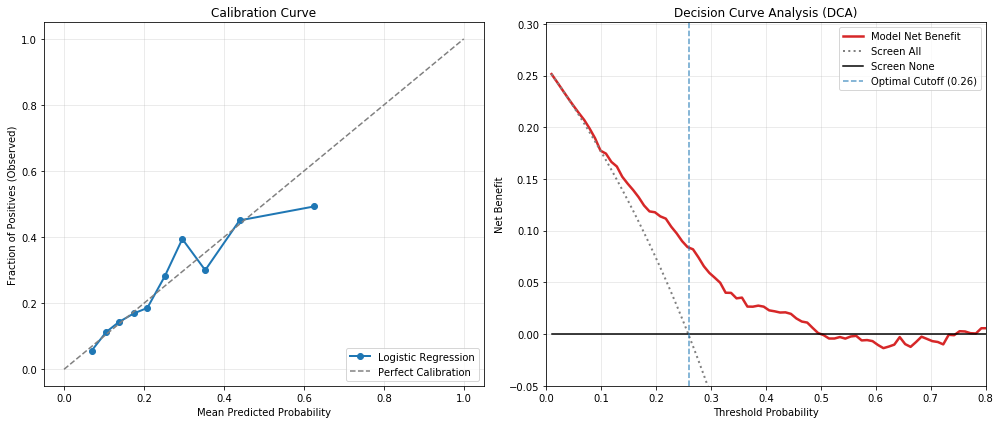

In [24]:
# ==============================================================================
# PHASE 6: CALIBRATION CURVE & DECISION CURVE ANALYSIS (DCA) PLOTTING
# ==============================================================================
def calculate_net_benefit(y_true, y_prob, pt_arr):
    net_benefit = []
    N = len(y_true)
    for pt in pt_arr:
        if pt == 1.0:
            net_benefit.append(0)
            continue
        preds = (y_prob >= pt).astype(int)
        tp_count = np.sum((preds == 1) & (y_true == 1))
        fp_count = np.sum((preds == 1) & (y_true == 0))
        nb = (tp_count / N) - (fp_count / N) * (pt / (1 - pt))
        net_benefit.append(nb)
    return np.array(net_benefit)

pt_arr = np.linspace(0.01, 0.99, 100)
nb_model = calculate_net_benefit(y_test.values, y_prob_main, pt_arr)
overall_prevalence = np.mean(y_test.values)
nb_all = overall_prevalence - (1 - overall_prevalence) * (pt_arr / (1 - pt_arr))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_main, n_bins=10, strategy='quantile')
axes[0].plot(prob_pred, prob_true, marker='o', linewidth=2, color='tab:blue', label='Logistic Regression')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction of Positives (Observed)")
axes[0].set_title("Calibration Curve")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# 2. Decision Curve Analysis (DCA)
axes[1].plot(pt_arr, nb_model, color='tab:red', linewidth=2.5, label='Model Net Benefit')
axes[1].plot(pt_arr, nb_all, color='gray', linestyle=':', linewidth=2, label='Screen All')
axes[1].plot(pt_arr, np.zeros_like(pt_arr), color='black', linewidth=1.5, label='Screen None')
axes[1].axvline(x=best_thr, color='tab:blue', linestyle='--', alpha=0.7, label=f'Optimal Cutoff ({best_thr:.2f})')
axes[1].set_ylim([-0.05, max(np.max(nb_model), np.max(nb_all)) + 0.05])
axes[1].set_xlim([0.0, 0.8]) 
axes[1].set_xlabel("Threshold Probability")
axes[1].set_ylabel("Net Benefit")
axes[1].set_title("Decision Curve Analysis (DCA)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Calibration_DCA.jpg", dpi=400, bbox_inches="tight")
plt.show()

In [25]:
# ==============================================================================
# PHASE 7: INFERENTIAL ODDS RATIOS, CLINICAL UTILITY MATRIX & RISK FORMULA
# ==============================================================================

# ---------------------------------------------------------
# A. Clinical Odds Ratios (Crude vs. Multivariable)
# ---------------------------------------------------------
print("="*85)
print("   CLINICAL INCREMENT ODDS RATIOS (METABOLIC PREDICTORS) - Table 2")
print("="*85)

clinical_increments = {
    'age_m': 5.0, 'BMI (kg/m^2)': 5.0, 'alt_1': 10.0, 'ast_1': 10.0,
    'tg_1': 10.0, 'hdl_1': 10.0, 'ldl_1': 10.0, 'sbp_mean': 10.0, 'dbp_mean': 10.0
}

X_clinical = X_train_imp.copy()
for col, inc in clinical_increments.items():
    if col in X_clinical.columns:
        X_clinical[col] = X_clinical[col] / inc

X_clinical = X_clinical.apply(pd.to_numeric, errors='coerce').astype(float)
y_sm = y_train.values.astype(float)
X_mat = sm.add_constant(X_clinical)

crude_results = []
for col in X_clinical.columns:
    X_univ = sm.add_constant(X_clinical[[col]])
    try:
        crude_model = sm.Logit(y_sm, X_univ).fit(disp=0)
        or_val = np.exp(crude_model.params[col])
        ci_lower = np.exp(crude_model.conf_int().loc[col, 0])
        ci_upper = np.exp(crude_model.conf_int().loc[col, 1])
        pval = crude_model.pvalues[col]
    except:
        or_val, ci_lower, ci_upper, pval = np.nan, np.nan, np.nan, np.nan
        
    crude_results.append({
        "Feature": col, "Crude OR": or_val, 
        "Crude Lower 95% CI": ci_lower, "Crude Upper 95% CI": ci_upper, "Crude p-value": pval
    })

crude_df = pd.DataFrame(crude_results).set_index("Feature")

try:
    multi_model = sm.Logit(y_sm, X_mat).fit(disp=0, method='bfgs')
    multi_df = pd.DataFrame({
        "Multi OR": np.exp(multi_model.params),
        "Multi Lower 95% CI": np.exp(multi_model.conf_int()[0]),
        "Multi Upper 95% CI": np.exp(multi_model.conf_int()[1]),
        "Multi p-value": multi_model.pvalues
    }).drop(index="const", errors="ignore")
    
    final_coef_table = crude_df.join(multi_df).round(3)
    display(final_coef_table)
except Exception as e:
    print(f"Error in Multivariable model: {e}")

# ---------------------------------------------------------
# B. Clinical Utility Metrics Across Plausible Thresholds
# ---------------------------------------------------------
print("\n" + "="*85)
print("   CLINICAL UTILITY METRICS ACROSS PLAUSIBLE RISK THRESHOLDS (Test Set) - Supp Table 4")
print("="*85)

eval_thresholds = [0.10, 0.15, 0.20, 0.22, 0.25, 0.30, 0.40, 0.50]
utility_rows = []

for thr in eval_thresholds:
    preds = (y_prob_main >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    utility_rows.append({
        "Threshold": f"> {thr*100:.0f}% Risk",
        "Sensitivity (%)": sens * 100,
        "Specificity (%)": spec * 100,
        "PPV (%)": ppv * 100,
        "NPV (%)": npv * 100,
        "False Positives": fp,
        "False Negatives": fn
    })

utility_df = pd.DataFrame(utility_rows).set_index("Threshold").round(1)
display(utility_df)

# ---------------------------------------------------------
# C. Unscaling the Coefficients for the Absolute Risk Formula
# ---------------------------------------------------------
print("\n" + "="*85)
print("   ABSOLUTE RISK FORMULA (REAL-WORLD CLINICAL COEFFICIENTS)")
print("="*85)

scaler = main_model.named_steps['scaler']
clf = main_model.named_steps['clf']

coef_scaled = clf.coef_[0]
intercept_scaled = clf.intercept_[0]
means = scaler.mean_
scales = scaler.scale_

coef_raw = coef_scaled / scales
intercept_raw = intercept_scaled - np.sum((coef_scaled * means) / scales)

print(f"Base Intercept (β0): {intercept_raw:.4f}\n")
print("Clinical Coefficients (β):")

formula_terms = [f"{intercept_raw:.4f}"]
for feature_name, coef in zip(X_test_imp.columns, coef_raw):
    print(f" - {feature_name:15s}: {coef:.4f}")
    if coef >= 0:
        formula_terms.append(f"+ ({coef:.4f} × {feature_name})")
    else:
        formula_terms.append(f"- ({abs(coef):.4f} × {feature_name})")

equation_string = " ".join(formula_terms)

print("\n--- Final Clinical Equation (Log-Odds) ---")
print(f"Log-Odds (L) = {equation_string}")
print("\nProbability of MASLD = 1 / (1 + e^(-L))")

   CLINICAL INCREMENT ODDS RATIOS (METABOLIC PREDICTORS) - Table 2


,Crude OR,Crude Lower 95% CI,Crude Upper 95% CI,Crude p-value,Multi OR,Multi Lower 95% CI,Multi Upper 95% CI,Multi p-value
Feature,,,,,,,,
alt_1,1.211,1.114,1.315,0.000,1.258,1.106,1.432,0.000
ast_1,1.077,0.956,1.215,0.222,0.797,0.639,0.994,0.045
tg_1,1.057,1.042,1.073,0.000,1.029,1.012,1.047,0.001
hdl_1,0.866,0.801,0.936,0.000,0.933,0.843,1.032,0.179
ldl_1,1.059,1.026,1.093,0.000,1.022,0.985,1.060,0.246
sex,0.853,0.684,1.066,0.162,1.300,0.963,1.755,0.087
age_m,1.018,0.982,1.055,0.344,0.923,0.879,0.969,0.001
m_hbsab_1,0.701,0.548,0.896,0.005,0.770,0.590,1.006,0.055
m_smoke_1,0.843,0.622,1.143,0.272,0.965,0.674,1.382,0.847



   CLINICAL UTILITY METRICS ACROSS PLAUSIBLE RISK THRESHOLDS (Test Set) - Supp Table 4


,Sensitivity (%),Specificity (%),PPV (%),NPV (%),False Positives,False Negatives
Threshold,,,,,,
> 10% Risk,95.1,16.4,28.4,90.5,438,9
> 15% Risk,89.1,34.7,32.3,90.1,342,20
> 20% Risk,80.9,50.8,36.5,88.4,258,35
> 22% Risk,78.1,56.9,38.8,88.2,226,40
> 25% Risk,69.9,62.8,39.6,85.7,195,55
> 30% Risk,54.6,73.7,42.0,82.3,138,83
> 40% Risk,34.4,87.0,48.1,79.2,68,120
> 50% Risk,19.1,93.3,50.0,76.8,35,148



   ABSOLUTE RISK FORMULA (REAL-WORLD CLINICAL COEFFICIENTS)
Base Intercept (β0): -6.2329

Clinical Coefficients (β):
 - alt_1          : 0.0141
 - ast_1          : -0.0072
 - tg_1           : 0.0030
 - hdl_1          : -0.0017
 - ldl_1          : 0.0022
 - sex            : 0.2648
 - age_m          : -0.0129
 - m_hbsab_1      : -0.3044
 - m_smoke_1      : -0.0290
 - m_metsatp3_1   : 0.1583
 - m_lipm_1       : 0.2424
 - m_htnm_1       : 0.3139
 - m_t2dm_1       : -0.1638
 - sbp_mean       : 0.0091
 - dbp_mean       : -0.0074
 - BMI (kg/m^2)   : 0.1704

--- Final Clinical Equation (Log-Odds) ---
Log-Odds (L) = -6.2329 + (0.0141 × alt_1) - (0.0072 × ast_1) + (0.0030 × tg_1) - (0.0017 × hdl_1) + (0.0022 × ldl_1) + (0.2648 × sex) - (0.0129 × age_m) - (0.3044 × m_hbsab_1) - (0.0290 × m_smoke_1) + (0.1583 × m_metsatp3_1) + (0.2424 × m_lipm_1) + (0.3139 × m_htnm_1) - (0.1638 × m_t2dm_1) + (0.0091 × sbp_mean) - (0.0074 × dbp_mean) + (0.1704 × BMI (kg/m^2))

Probability of MASLD = 1 / (1 + e^(-L

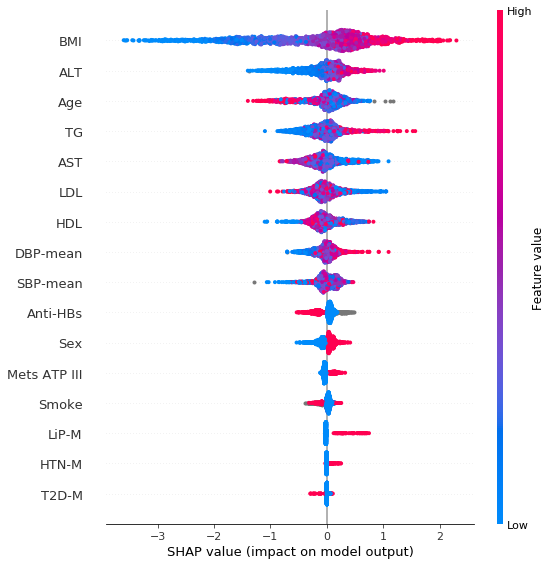

In [29]:
# ==== XGBoost SHAP summary plot (107 mm width @ 300 dpi + renamed labels) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier

# If you haven't already imputed X for this specific script, make sure to do it!
# Assuming 'X' and 'y' here are your clean, strictly metabolic variables 
# (e.g., X_sens from the previous script)

RANDOM_STATE = 42

# ---- journal sizing ----
MM_TO_IN = 1 / 25.4
FIG_W_IN = 107 * MM_TO_IN          # 107 mm wide (standard 1-column journal width)
FIG_H_IN = 80 * MM_TO_IN           # 80 mm height

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 8,
})

# ---- fit XGB on full data (Natural Prevalence - NO scale_pos_weight) ----
xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=3.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="logloss"
    # Removed scale_pos_weight to perfectly match your LR methodology
    # Removed use_label_encoder=False as it is deprecated
)

xgb.fit(X, y)

# ---- sample rows for SHAP speed (Optional) ----
MAX_ROWS = 2000
if len(X) > MAX_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    samp_idx = rng.choice(X.index, size=MAX_ROWS, replace=False)
    X_for_shap = X.loc[samp_idx]
else:
    X_for_shap = X.copy()

# ---- rename ONLY for display (does NOT affect training) ----
name_map = {
    "BMI (kg/m^2)": "BMI",
    "m_sld_1": "Baseline SLD", # Left this in case you plot the sensitivity dataset
    "alt_1": "ALT",
    "age_m": "Age",
    "ast_1": "AST",
    "tg_1": "TG",
    "sex": "Sex",
    "m_hbsab_1": "Anti-HBs",
    "dbp_mean": "DBP-mean",
    "m_fbs_1": "FBS",
    "m_smoke_1": "Smoke",
    "m_lipm_1": "LiP-M",
    "hdl_1": "HDL",
    "m_htnm_1": "HTN-M",
    "sbp_mean": "SBP-mean",
    "m_t2dm_1": "T2D-M",
    "ldl_1": "LDL",
    "m_metsatp3_1": "Mets ATP III"
}

# Rename columns for the plot. (Will only rename columns that actually exist in X)
X_disp = X_for_shap.rename(columns=name_map)

# ---- SHAP ----
explainer = shap.TreeExplainer(xgb)

# Create figure at required final size BEFORE calling summary_plot
plt.figure(figsize=(FIG_W_IN, FIG_H_IN))

try:
    explanation = explainer(X_for_shap)
    shap.summary_plot(
        explanation.values,
        features=X_disp,                    # renamed display DF
        feature_names=X_disp.columns,
        show=False
    )
except Exception:
    # Fallback for older SHAP versions
    shap_values = explainer.shap_values(X_for_shap)
    shap.summary_plot(
        shap_values,
        features=X_disp,                    
        feature_names=X_disp.columns,
        show=False
    )

# Clean up layout so labels don't get cut off
plt.tight_layout()

# ---- save at 300 dpi, 107 mm wide ----
plt.savefig("shap_summary_107mm_300dpi.tif", dpi=300, bbox_inches="tight")
plt.savefig("shap_summary_107mm_300dpi.jpg", dpi=300, bbox_inches="tight")

plt.show()